# E-commerce Fulfilment & Delivery Performance Analysis

## Notebook 03: Exploratory Data Analysis

This notebook focuses on exploring the analysis-ready Olist e-commerce dataset.

The purpose of this notebook is to:

- Review the cleaned master dataset
- Calculate key fulfilment and delivery KPIs
- Analyse late delivery performance
- Explore review score patterns
- Compare freight cost by product category
- Identify useful insights for SQL, Power BI and business recommendations

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define file paths

processed_data_path = Path("../data/processed")
analysis_file = processed_data_path / "analysis_ready_orders.csv"

print("Analysis file exists:", analysis_file.exists())

Analysis file exists: True


In [3]:
# Load analysis-ready dataset

orders = pd.read_csv(analysis_file)

print("Dataset loaded successfully.")
print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

Dataset loaded successfully.
Rows: 96478
Columns: 32


In [4]:
# Preview the first rows

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_delivery_days,...,total_payment_value,max_payment_installments,avg_review_score,review_count,main_product_category,main_seller_state,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,38.71,1.0,4.0,1.0,housewares,SP,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,141.46,1.0,4.0,1.0,perfumery,SP,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,179.12,3.0,5.0,1.0,auto,SP,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,...,72.20,1.0,5.0,1.0,pet_shop,MG,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,...,28.62,1.0,5.0,1.0,stationery,SP,250.0,51.0,15.0,15.0


In [5]:
# Check column names

orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'estimated_delivery_days',
 'delay_days',
 'is_late_delivery',
 'customer_unique_id',
 'customer_city',
 'customer_state',
 'order_item_count',
 'product_count',
 'seller_count',
 'total_item_value',
 'total_freight_value',
 'avg_item_price',
 'payment_count',
 'total_payment_value',
 'max_payment_installments',
 'avg_review_score',
 'review_count',
 'main_product_category',
 'main_seller_state',
 'avg_product_weight_g',
 'avg_product_length_cm',
 'avg_product_height_cm',
 'avg_product_width_cm']

In [6]:
# Check data types

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96478 non-null  str    
 1   customer_id                    96478 non-null  str    
 2   order_status                   96478 non-null  str    
 3   order_purchase_timestamp       96478 non-null  str    
 4   order_approved_at              96464 non-null  str    
 5   order_delivered_carrier_date   96476 non-null  str    
 6   order_delivered_customer_date  96470 non-null  str    
 7   order_estimated_delivery_date  96478 non-null  str    
 8   delivery_days                  96470 non-null  float64
 9   estimated_delivery_days        96478 non-null  int64  
 10  delay_days                     96470 non-null  float64
 11  is_late_delivery               96478 non-null  bool   
 12  customer_unique_id             96478 non-null  str    
 1

## Key Performance Indicators

In this section, I will calculate the main KPIs for delivery and fulfilment performance.

These KPIs help summarise the overall performance of the delivered orders in the dataset.

In [7]:
# Calculate key KPIs

total_orders = len(orders)
late_orders = orders["is_late_delivery"].sum()
late_delivery_rate = late_orders / total_orders

average_delivery_days = orders["delivery_days"].mean()
average_delay_days = orders["delay_days"].mean()
average_review_score = orders["avg_review_score"].mean()
average_freight_value = orders["total_freight_value"].mean()
average_order_value = orders["total_item_value"].mean()

kpi_summary = pd.DataFrame([
    {"KPI": "Total Delivered Orders", "Value": total_orders},
    {"KPI": "Late Delivered Orders", "Value": late_orders},
    {"KPI": "Late Delivery Rate", "Value": f"{late_delivery_rate:.2%}"},
    {"KPI": "Average Delivery Days", "Value": round(average_delivery_days, 2)},
    {"KPI": "Average Delay Days", "Value": round(average_delay_days, 2)},
    {"KPI": "Average Review Score", "Value": round(average_review_score, 2)},
    {"KPI": "Average Freight Value", "Value": round(average_freight_value, 2)},
    {"KPI": "Average Item Value", "Value": round(average_order_value, 2)}
])

kpi_summary

,KPI,Value
0,Total Delivered Orders,96478
1,Late Delivered Orders,6534
2,Late Delivery Rate,6.77%
3,Average Delivery Days,12.09
4,Average Delay Days,-11.88
5,Average Review Score,4.16
6,Average Freight Value,22.79
7,Average Item Value,137.04


## Late Delivery and Review Score

This section checks whether late deliveries appear to be linked with lower customer review scores.

This is important because delivery performance can directly affect customer satisfaction.

In [8]:
# Compare review score for late and on-time deliveries

review_by_delivery_status = (
    orders
    .groupby("is_late_delivery")
    .agg(
        order_count=("order_id", "count"),
        average_review_score=("avg_review_score", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

review_by_delivery_status["delivery_status"] = review_by_delivery_status["is_late_delivery"].map({
    False: "On time or early",
    True: "Late"
})

review_by_delivery_status

,is_late_delivery,order_count,average_review_score,average_delivery_days,average_delay_days,delivery_status
0,False,89944,4.290608,10.539261,-13.510263,On time or early
1,True,6534,2.271823,33.488062,10.620141,Late


## Customer State Analysis

This section shows where delivered orders are concentrated by customer state.

This can help identify regions with higher order volumes and possible delivery pressure.

In [9]:
# Top customer states by order volume

state_summary = (
    orders
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "count"),
        late_orders=("is_late_delivery", "sum"),
        average_review_score=("avg_review_score", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_freight_value=("total_freight_value", "mean")
    )
    .reset_index()
)

state_summary["late_delivery_rate"] = state_summary["late_orders"] / state_summary["order_count"]

state_summary.sort_values(by="order_count", ascending=False).head(10)

,customer_state,order_count,late_orders,average_review_score,average_delivery_days,average_freight_value,late_delivery_rate
25,SP,40501,1820,4.246551,8.298094,17.334633,0.044937
18,RJ,12350,1495,3.965141,14.848583,23.947404,0.121053
10,MG,11354,519,4.192468,11.542188,23.463963,0.045711
22,RS,5345,325,4.185752,14.819237,24.803615,0.060804
17,PR,4923,199,4.239592,11.526711,23.490817,0.040423
23,SC,3546,291,4.133276,14.475183,24.849309,0.082064
4,BA,3256,396,3.930009,18.866400,29.961201,0.121622
6,DF,2080,118,4.133816,12.509135,23.858144,0.056731
7,ES,1995,214,4.079736,15.331830,24.568662,0.107268
8,GO,1957,128,4.104317,15.150741,26.252248,0.065406


## Product Category Analysis

This section explores delivery, freight and review patterns by product category.

This can help identify whether some product categories are linked with higher freight costs or poorer delivery outcomes.

In [10]:
# Product category summary

category_summary = (
    orders
    .groupby("main_product_category")
    .agg(
        order_count=("order_id", "count"),
        late_orders=("is_late_delivery", "sum"),
        average_review_score=("avg_review_score", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_freight_value=("total_freight_value", "mean"),
        average_item_value=("total_item_value", "mean")
    )
    .reset_index()
)

category_summary["late_delivery_rate"] = category_summary["late_orders"] / category_summary["order_count"]

category_summary.sort_values(by="order_count", ascending=False).head(10)

,main_product_category,order_count,late_orders,average_review_score,average_delivery_days,average_freight_value,average_item_value,late_delivery_rate
7,bed_bath_table,9240,689,4.003171,12.531926,22.150877,112.131253,0.074567
43,health_beauty,8621,649,4.232284,11.628929,20.788913,143.230798,0.075281
65,sports_leisure,7478,493,4.238095,11.797379,21.773625,127.409593,0.065927
15,computers_accessories,6520,417,4.082293,12.731554,22.203535,136.850342,0.063957
39,furniture_decor,6208,446,4.073109,12.641430,27.232068,115.245623,0.071843
49,housewares,5671,308,4.207380,10.645212,25.072530,108.068960,0.054311
70,watches_gifts,5455,406,4.129640,12.365304,17.895665,212.688192,0.074427
68,telephony,4071,291,4.058068,12.493491,16.979828,75.893788,0.071481
5,auto,3804,278,4.147121,11.880884,23.861207,152.716932,0.073081
69,toys,3759,241,4.248190,11.294838,20.001625,124.308406,0.064113


## Initial Visual Exploration

The following charts provide a quick visual overview of key fulfilment and delivery patterns.

More polished dashboard visuals will be created later in Power BI.

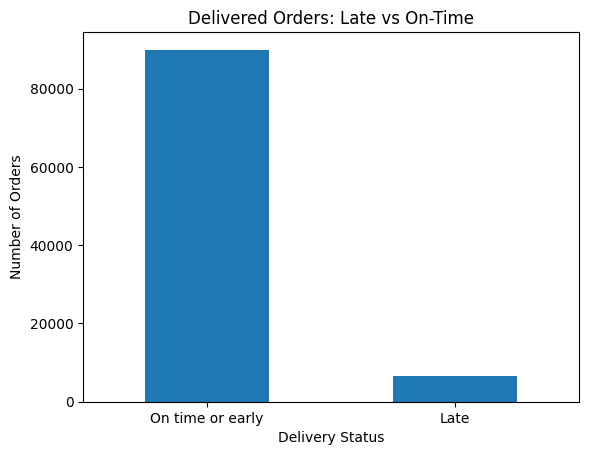

In [11]:
# Bar chart: late vs on-time orders

delivery_status_counts = orders["is_late_delivery"].value_counts().rename(index={
    False: "On time or early",
    True: "Late"
})

delivery_status_counts.plot(kind="bar")
plt.title("Delivered Orders: Late vs On-Time")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

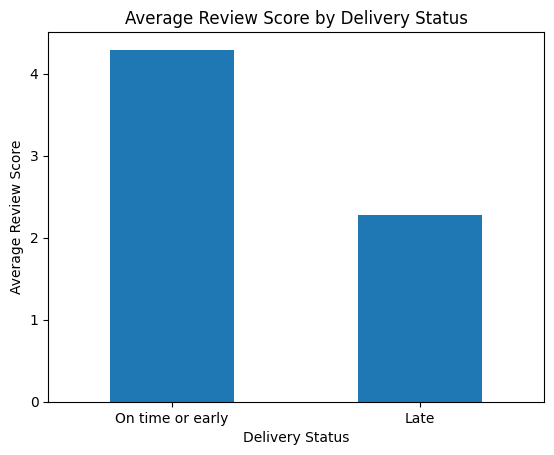

In [12]:
# Bar chart: average review score by delivery status

review_chart_data = review_by_delivery_status.set_index("delivery_status")["average_review_score"]

review_chart_data.plot(kind="bar")
plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.show()

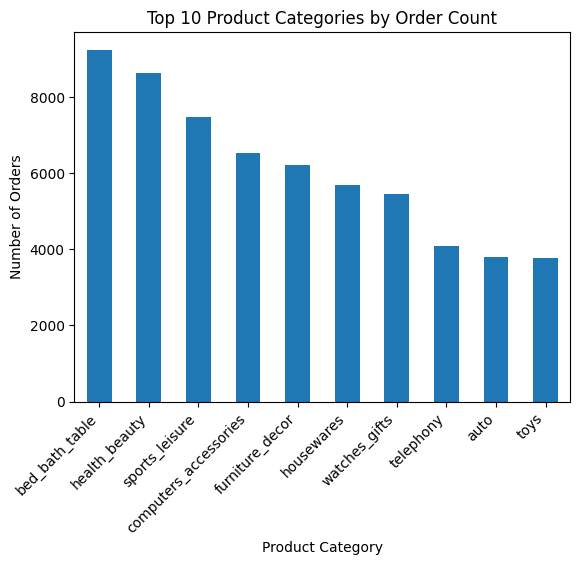

In [13]:
# Top 10 product categories by order count

top_categories = category_summary.sort_values(by="order_count", ascending=False).head(10)

top_categories.set_index("main_product_category")["order_count"].plot(kind="bar")
plt.title("Top 10 Product Categories by Order Count")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.show()

## Export EDA Summary Tables

The summary tables created in this notebook will be exported to the processed data folder.

These can be reused later in reports, SQL comparison work or Power BI.

In [14]:
# Export EDA summary tables

kpi_summary.to_csv(processed_data_path / "kpi_summary.csv", index=False)
review_by_delivery_status.to_csv(processed_data_path / "review_by_delivery_status.csv", index=False)
state_summary.to_csv(processed_data_path / "state_summary.csv", index=False)
category_summary.to_csv(processed_data_path / "category_summary.csv", index=False)

print("EDA summary tables exported successfully.")

EDA summary tables exported successfully.


In [15]:
# Check exported files

for file_name in [
    "kpi_summary.csv",
    "review_by_delivery_status.csv",
    "state_summary.csv",
    "category_summary.csv"
]:
    file_path = processed_data_path / file_name
    print(file_name, file_path.exists())

kpi_summary.csv True
review_by_delivery_status.csv True
state_summary.csv True
category_summary.csv True
